# <a id='toc1_'></a>[Bericht zur Datenqualität (epi2025_beta)](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Bericht zur Datenqualität (epi2025_beta)](#toc1_)    
  - [Änderungen seit der letzten Version](#toc1_1_)    
  - [Hinweise](#toc1_2_)    
  - [Datenstand](#toc1_3_)    
  - [Fallzahlen im Verlauf der Jahreslieferungen](#toc1_4_)    
    - [original geliefert vor ZfKD Prüfungen](#toc1_4_1_)    
    - [jeweils letztes DJ nach ZfKD  Prüfungen](#toc1_4_2_)    
  - [Variablenverteilung](#toc1_5_)    
    - [Diagnosejahr](#toc1_5_1_)    
    - [Diagnosegruppen](#toc1_5_2_)    
    - [Diagnosesicherung](#toc1_5_3_)    
    - [DCO Diagramm](#toc1_5_4_)    
    - [DCO](#toc1_5_5_)    
    - [Angabe Register vs Bundesland](#toc1_5_6_)    
    - [Dignität](#toc1_5_7_)    
    - [Grading Verteilung](#toc1_5_8_)    
    - [Grading Anteil](#toc1_5_9_)    
    - [Altersgruppen](#toc1_5_10_)    
    - [UICC](#toc1_5_11_)    
    - [TNM-Auflage](#toc1_5_12_)    
    - [Tod](#toc1_5_13_)    
      - [Anteil Verstorbene](#toc1_5_13_1_)    
      - [Verteilung Todesursachen nach ICDT10](#toc1_5_13_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

<br>

## <a id='toc1_1_'></a>[Änderungen seit der letzten Version](#toc0_)
<!-- - bisher wurden folgende Angaben in einer umfangreichen Verarbeitung im workflow umkodiert: `ICDGM10`, `HISC`, `ICDO3`, `DIG`. Diese Umformung wurde deaktiviert, es finden nun nur noch punktuelle Korrekturen statt -->
- Lieferung Daten mit DJ=2024
- ausstehend: `13-MV`

<br>

## <a id='toc1_2_'></a>[Hinweise](#toc0_)
- Bewertungen der Analysen sind mit 💡 markiert
- bei den Plausibilitätsprüfungen weist ein ✅ darauf hin, dass keine Mängel erkennbar sind

<br>

## <a id='toc1_3_'></a>[Datenstand](#toc0_)

In [1]:
import os
from pathlib import Path
import pandas as pd
import datetime as dt
from pandas_plots import tbl, pls, hlp, const
import duckdb as ddb

from connection_helper import sql
import numpy as np

os.environ["DY_MAX"] = "2024"  # set before import
from mod.filters import *

os.environ['THEME']='light'
# hlp.show_package_version()

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

# file_epi = dir_db/'2025-11-06_data_epi.duckdb'
# file_meta = dir_db/'2025-11-06_meta_epi.duckdb'
file_epi = dir_db/'2026-03-03_data_epi.duckdb'
# file_meta = dir_db/'2026-03-03_meta_epi.duckdb'

if not file_epi.exists():
    raise Exception(f"files {file_epi} not found")

URL_V2 = 'https://gitlab.opencode.de/robert-koch-institut/zentrum-fuer-krebsregisterdaten/cancerdata-references/-/raw/main/data/v2/'

hlp.setup_rendering(True)

In [2]:
sql.print_meta(file_epi)

database file:           2026-03-03_data_epi.duckdb
data tag:                epi2025_beta2
sql table created:       2026-03-03 09:47:44
doi:                     -
document created:        2026-04-21 16:19:58


In [3]:
FILTERS_DY_RANGE = ("z_dy between 2019 and 2025", "DJ 2019-2025")

In [4]:
_=con = ddb.connect(file_epi, read_only=True)
_=con.execute("PRAGMA disable_progress_bar;")

In [5]:
# dim_dig = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/dig.csv", sep=";")
# dim_dsich_epi = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/diagnosesicherung_epi.csv", sep=";")
# dim_grading_epi = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/grading_epi.csv", sep=";")
# dim_icd10_3d = sql.load_file_to_duckdb(con, URL_V2 + "Aggregationen/icd10_3d.csv", sep=";")
dim_lieferregister = con.table("dim_lieferregister").to_df()

In [6]:
Batches = con.table("_batches")
Checks = con.table("_checks")
ColumnCheck = con.table("_columncheck")
Frequencies = con.table("_frequencies")
# _meta_meta = con.sql("select * from meta._meta;")

df_checks = Checks.to_df().astype({"EKRNR": str})
df_freqs = (
    Frequencies.project(
        "*, concat(cast(BatchID as varchar),' | ', cast(cast(BatchZeit as date) as varchar)) as batch_label"
    )
    .to_df()
    .astype({"EKRNR": str})
)
df_freqs["EKRNR"] = df_freqs["EKRNR"].astype(int).replace(dim_lieferregister["kkr"].to_dict())
df_checks["EKRNR"] = df_checks["EKRNR"].astype(int).replace(dim_lieferregister["kkr"].to_dict())
df_batches= Batches.to_df()
df_columnchecks= ColumnCheck.to_df().set_index('ColumnCheckID')
df_checks = df_checks.join(df_columnchecks, on='ColumnCheckID')
df_checks["check_label"] = df_checks.apply(lambda x: f"{x['Alias']}[{x['ColumnCheckID']}]", axis=1)
df_checks= df_checks[["EKRNR","Anzahl","BatchID","DJahr","check_label","ColumnCheckID"]]

In [7]:
# db_epi = con.sql("select * from tumor_epi_clin_all;")

In [8]:
batch_max=df_checks['BatchID'].max()
batch_list = [batch_max,418,416,399,360]
batch_min=399
db_list_dy="(2024)"    # must be a str list, since "alt" is in dy col - or a ddb compatible str

In [9]:
print(f"\n{'aktuellster batch': <32}{batch_max}")
print(f"{'aktuellstes Diagnosejahr 📆': <30} {db_list_dy}")


aktuellster batch               425
aktuellstes Diagnosejahr 📆     (2024)


<div style="page-break-after: always;"></div>

## <a id='toc1_4_'></a>[Fallzahlen im Verlauf der Jahreslieferungen](#toc0_)
- kein Filter
- es werden Datenstände (_batch_) aus mehreren Lieferjahren dargestellt , welche über eine laufende Nummer sowie das Datum der Ausführung vergleichbar sind
- in Abgrenzung zu den klinischen Daten ist jede einzelne EKR Lieferung für das gesamte Lieferjahr gültig
- dargestellt sind die **letzten 5 veröffentlichten** Datenstände 

<br>

### <a id='toc1_4_1_'></a>[original geliefert vor ZfKD Prüfungen](#toc0_)
- die Übersicht macht erkennbar, wie sich die Fallzahlen absolut und relativ im Laufe der letzten Lieferungen entwickelt haben
- aufgeführt sind die Fallzahlen aus den überlieferten Dateien **vor** den ZfKD Anpassungen
- `batch_label` markiert den jeweils letzten offiziellen Datenstand des Lieferjahres, sowie den aktuellen Datenstand

In [10]:
_df=df_freqs[(df_freqs.Stufe==2) & (df_freqs.Alias=="SEX") & (df_freqs.BatchID.isin(batch_list))]
_df=_df.pivot_table(index="batch_label", columns="EKRNR", values="Anzahl", aggfunc="sum")
tbl.show_num_df(
    _df,
    total_axis="y",
    data_bar_axis="x",
    font_size_th=12,
    font_size_td=11,
    col1_width=135,
)

EKRNR,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,Total
batch_label,,,,,,,,,,,,
360 | 2023-01-03,624_239,371_807,1_545_623,132_265,2_906_452,782_871,632_930,766_070,1_535_587,360_943,3_605_815,13_264_602
399 | 2024-12-02,734_305,423_109,1_816_413,151_753,3_991_177,918_534,823_343,1_048_203,1_811_372,400_646,3_792_956,15_911_811
416 | 2025-04-01,780_626,445_714,1_911_528,157_932,4_186_192,958_031,863_935,1_152_455,1_916_313,412_559,3_974_287,16_759_572
418 | 2025-06-20,780_626,445_714,1_911_528,157_932,4_186_192,973_597,863_935,1_152_455,1_916_313,412_559,3_950_260,16_751_111
425 | 2026-03-03,824_131,462_565,2_007_107,162_936,4_404_285,1_010_507,903_789,1_259_176,2_030_094,429_016,4_075_410,17_569_016


<br>

### <a id='toc1_4_2_'></a>[jeweils letztes DJ nach ZfKD  Prüfungen](#toc0_)
- Filter: jeweils das **letzte DJ** der einzelnen Jahreslieferung
- aufgeführt sind die Fallzahlen aus den überlieferten Dateien **nach** den ZfKD Anpassungen

In [11]:
_df=df_freqs[
    (df_freqs.Stufe==5) & 
    (df_freqs.Alias=="SEX") & 
    (df_freqs.BatchID.isin(batch_list))
    & (df_freqs.DJahr!="alt")
    ]
_df=_df.pivot_table(index="batch_label", columns="EKRNR", values="Anzahl", aggfunc="sum")
tbl.show_num_df(
    _df,
    total_axis="y",
    data_bar_axis="x",
    font_size_th=12,
    font_size_td=11,
    col1_width=135,
)

EKRNR,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,Total
batch_label,,,,,,,,,,,,
360 | 2023-01-03,32_401,17_099,81_092,6_548,176_210,38_279,25_194,77_968,85_001,11_391,164_812,715_995
399 | 2024-12-02,33_243,18_238,85_016,6_086,193_412,38_294,28_779,78_883,80_929,11_665,162_633,737_178
416 | 2025-04-01,34_512,18_011,86_331,5_068,202_655,30_291,30_000,81_600,84_717,11_076,157_970,742_231
418 | 2025-06-20,34_512,18_011,86_331,5_068,202_655,44_073,30_000,81_320,84_717,11_076,155_450,753_213
425 | 2026-03-03,36_307,17_987,84_692,4_687,191_487,31_633,31_489,82_957,86_674,12_247,125_790,705_950


In [12]:
# # * internal check
# _df=(df_checks[(df_checks.ColumnCheckID==48) & (df_checks.BatchID >= batch_min) & (df_checks.BatchID != 415)].sort_values('BatchID'))
# _df=_df.pivot_table(index="BatchID", columns="EKRNR", values="Anzahl", aggfunc="sum").fillna(0)
# tbl.show_num_df(_df, total_axis="y", data_bar_axis="x")

<div style="page-break-after: always;"></div>

## <a id='toc1_5_'></a>[Variablenverteilung](#toc0_)
<!-- - **Filter:**
  - **🚨 sofern nicht anders angegeben ist der Zeitraum beschränkt auf das höchste Diagnosejahr (für `epi2024`: 2023) 🚨**
  - Diagnosen: ausgeschlossen sind `C44` und alle `D` -->
- ab hier wird nur noch die **aktuelle Datenlieferung** dargestellt
- als ungültig markierte Fälle (_A-Prüfungen_) sind in allen Fallzahlen **ausgeschlossen**
- in den barplots sind die relativen Häufigkeiten von Variablen im Datensatz der Register aufgetragen
- zusätzlich ist die Angabe für alle Register enthalten (`Total`)
- näherungsweise sind **GKZ-Bundesländer** verwendet anstatt Lieferregister, um 11-16 aufspannen zu können

<br>

### <a id='toc1_5_1_'></a>[Diagnosejahr](#toc0_)

In [13]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY_RANGE,
    FILTERS_C,
    FILTERS_NO_C44,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        z_dy,
        GKZbl_label as bl,
    from tumor_epi_clin_all tum
    where {_filter}
    """
).to_df()
# _df
tbl.pivot_df(
    _df,
    data_bar_axis="x",
    pct_axis="",
    total_axis="y",
    font_size_th=12,
    font_size_td=11,
    # color_highlight_style="bright",
)

<!-- START_TOKEN -->

n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2019-2025]:            n = 4_597_256  (26.2%) ░░░░░░░░░░░░░░░░░░░░░░░███████
└ [ICD10 nur C]:             n = 3_886_792  (22.1%) ░░░░░░░░░░░░░░░░░░░░░░░░██████
└ [keine C44,D04]:           n = 3_143_607  (17.9%) ░░░░░░░░░░░░░░░░░░░░░░░░░█████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy between 2019 and 2025
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
```

</details>

bl,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,12-BB,13-MV,14-SN,15-ST,16-TH,Total
z_dy,,,,,,,,,,,,,,,,,
2019,21_239,10_827,53_159,4_207,122_915,38_028,27_300,67_929,74_291,7_531,21_388,17_553,10_614,29_101,16_101,13_393,535_576
2020,20_993,10_966,52_251,4_102,118_076,37_558,26_316,64_986,71_852,6_981,20_069,16_821,10_784,27_027,16_153,12_636,517_571
2021,21_862,11_217,52_915,4_009,117_050,37_828,27_950,66_090,74_719,7_462,20_831,17_189,11_148,27_308,15_686,12_952,526_216
2022,21_427,11_176,52_738,4_242,118_908,38_702,27_531,66_004,78_390,7_309,21_138,16_962,10_860,27_402,15_939,12_958,531_686
2023,21_336,11_129,53_709,4_081,122_113,37_782,28_002,66_725,79_282,7_360,21_122,17_631,11_209,28_240,16_434,12_755,538_910
2024,20_990,11_523,51_848,4_002,108_880,27_048,27_003,66_506,73_594,7_330,21_012,17_683,852,27_994,15_796,11_587,493_648


### <a id='toc1_5_2_'></a>[Diagnosegruppen](#toc0_)

> 💡 **ZfKD**
>
> D-Diagnosen (Vorstufen & unsichere Befunde)
> * Die Anteile sind in fast allen Bundesländern sehr ähnlich. 
> * Das zeigt, dass die Meldungen aus der Pathologie deutschlandweit relativ einheitlich erfasst werden.
> * Die Werte sind ein gutes Zeichen für eine vergleichbare Datenqualität.
>
> ---
>
> C44 (Heller Hautkrebs)
> * Hier sind die Fallzahlen überall hoch, aber die Anteile in der Grafik schwanken stark. 
> * Das liegt zum einen an der hohen Entdeckungsrate durch das Hautkrebs-Screening. 
> * Der Hauptgrund für die Unterschiede sind jedoch die **Landesgesetze**: Je nach Bundesland werden einfache Fälle (wie Basaliome) unterschiedlich streng gemeldet oder vergütet. Während manche Länder noch fast alles erfassen, konzentrieren sich andere bereits auf die schweren, "prognostisch ungünstigen" Verläufe.

<!-- START_TOKEN -->

n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2024]:                   n = 705_950   (4.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy = 2024
```

</details>

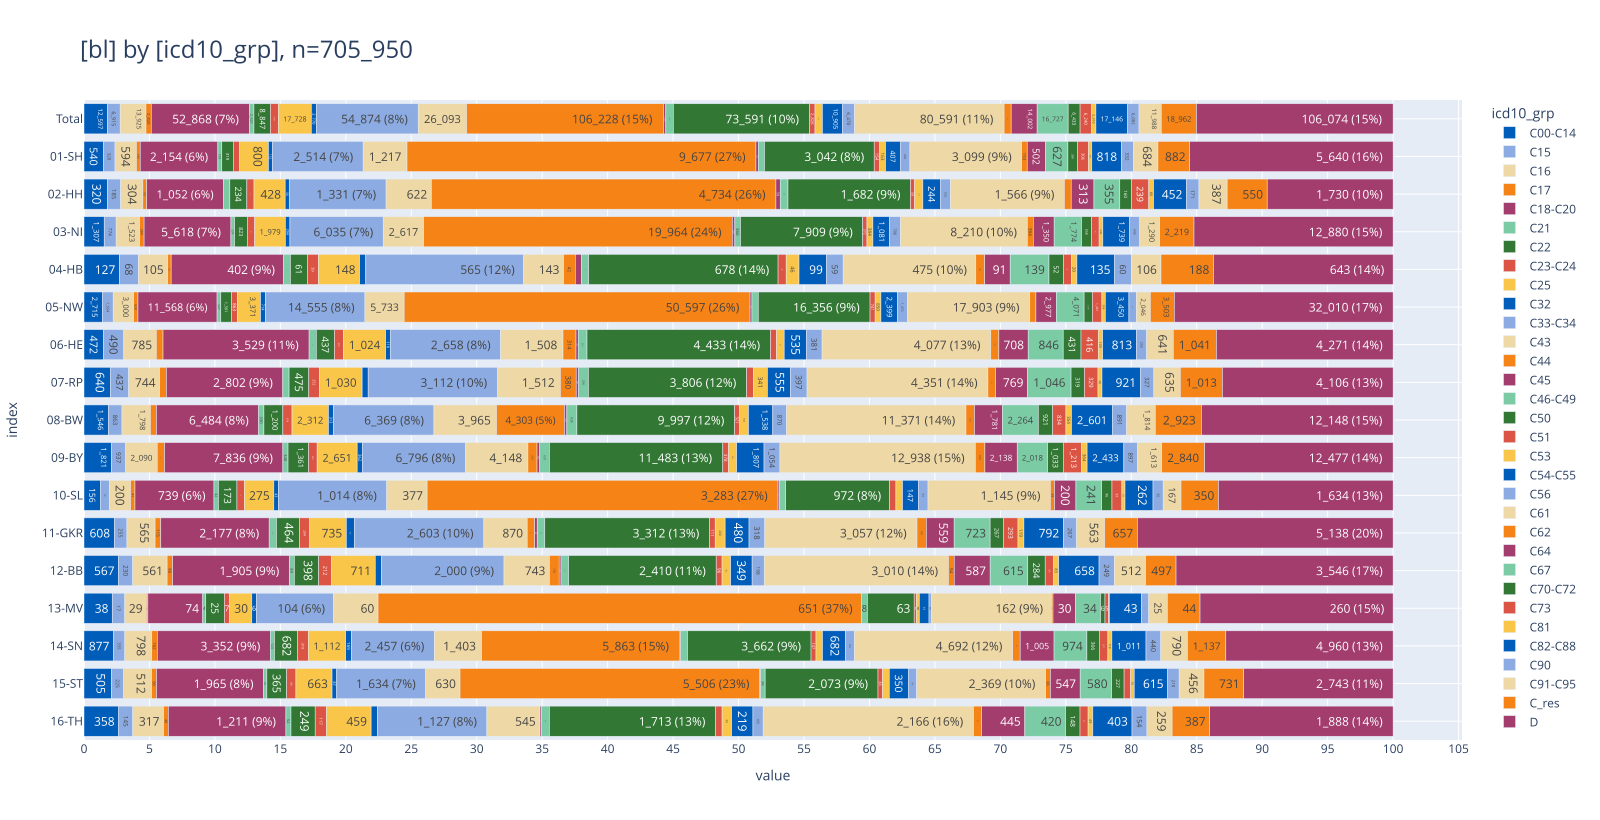

In [14]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY_MAX,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        --z_dy::text as z_dy,
        GKZbl_label as bl,
        code_kid as icd10_grp,
    from tumor_epi_clin_all tum
    left join dim_icd10_3d icd on tum.z_icd10_3d = icd.code
    where {_filter}
    """
).to_df()
# _df

_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=820,
    show_pct_bar=True,
)

<br>

### <a id='toc1_5_3_'></a>[Diagnosesicherung](#toc0_)

> 💡 **ZfKD**
> 
> - `08-BW` hat einen hohen Anteil an fehlenden Diagnosesicherungen mit zuletzt stark ansteigendem Trend
> - der Großteil der Meldungen basiert auf einer soliden feingeweblichen Untersuchung
> - in einigen LKR ist dieser Anteil erkennbar breiter als in anderen. Da die Zytologie oft bei Lungen- oder Schilddrüsenuntersuchungen genutzt wird, könnte dies auf eine starke Vernetzung mit entsprechenden Fachkliniken hindeuten, die ihre Befunde sehr detailliert an das Register melden.

In [28]:
# _filters = [
#     FILTERS_VALID,
#     FILTERS_DY_MAX,
#     FILTERS_C,
#     FILTERS_NO_C44,
# ]
# _filter = hlp.get_duckdb_filter_n(
#     con=con,
#     query="from tumor_epi_clin_all",
#     filters=_filters,
#     # distinct_metric="z_tum_id",
#     first_n_filter_apply_to_rows=0,
# )

# _df = con.sql(f"""--sql
#     select
#         --z_dy::text as z_dy,
#         GKZbl_label as bl,
#         label as DSICH,
#     from tumor_epi_clin_all tum
#     left join dim_dsich_epi ds on tum.DSICH::text = ds.code
#     where {_filter}
#     """
# ).to_df()
# _df

# _=pls.plot_stacked_bars(
#     _df,
#     orientation="h",
#     normalize=False,
#     relative=True,
#     dropna=False,
#     sort_values_index=False,
#     show_total=True,
#     height=700,
# )

<!-- START_TOKEN -->

n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ ab 2015]:              n = 7_603_415  (43.3%) ░░░░░░░░░░░░░░░░░░████████████
└ [ICD10 nur C]:             n = 6_499_552  (37.0%) ░░░░░░░░░░░░░░░░░░░███████████
└ [keine C44,D04]:           n = 5_194_820  (29.6%) ░░░░░░░░░░░░░░░░░░░░░░████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and DJ >= 2015
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
```

</details>

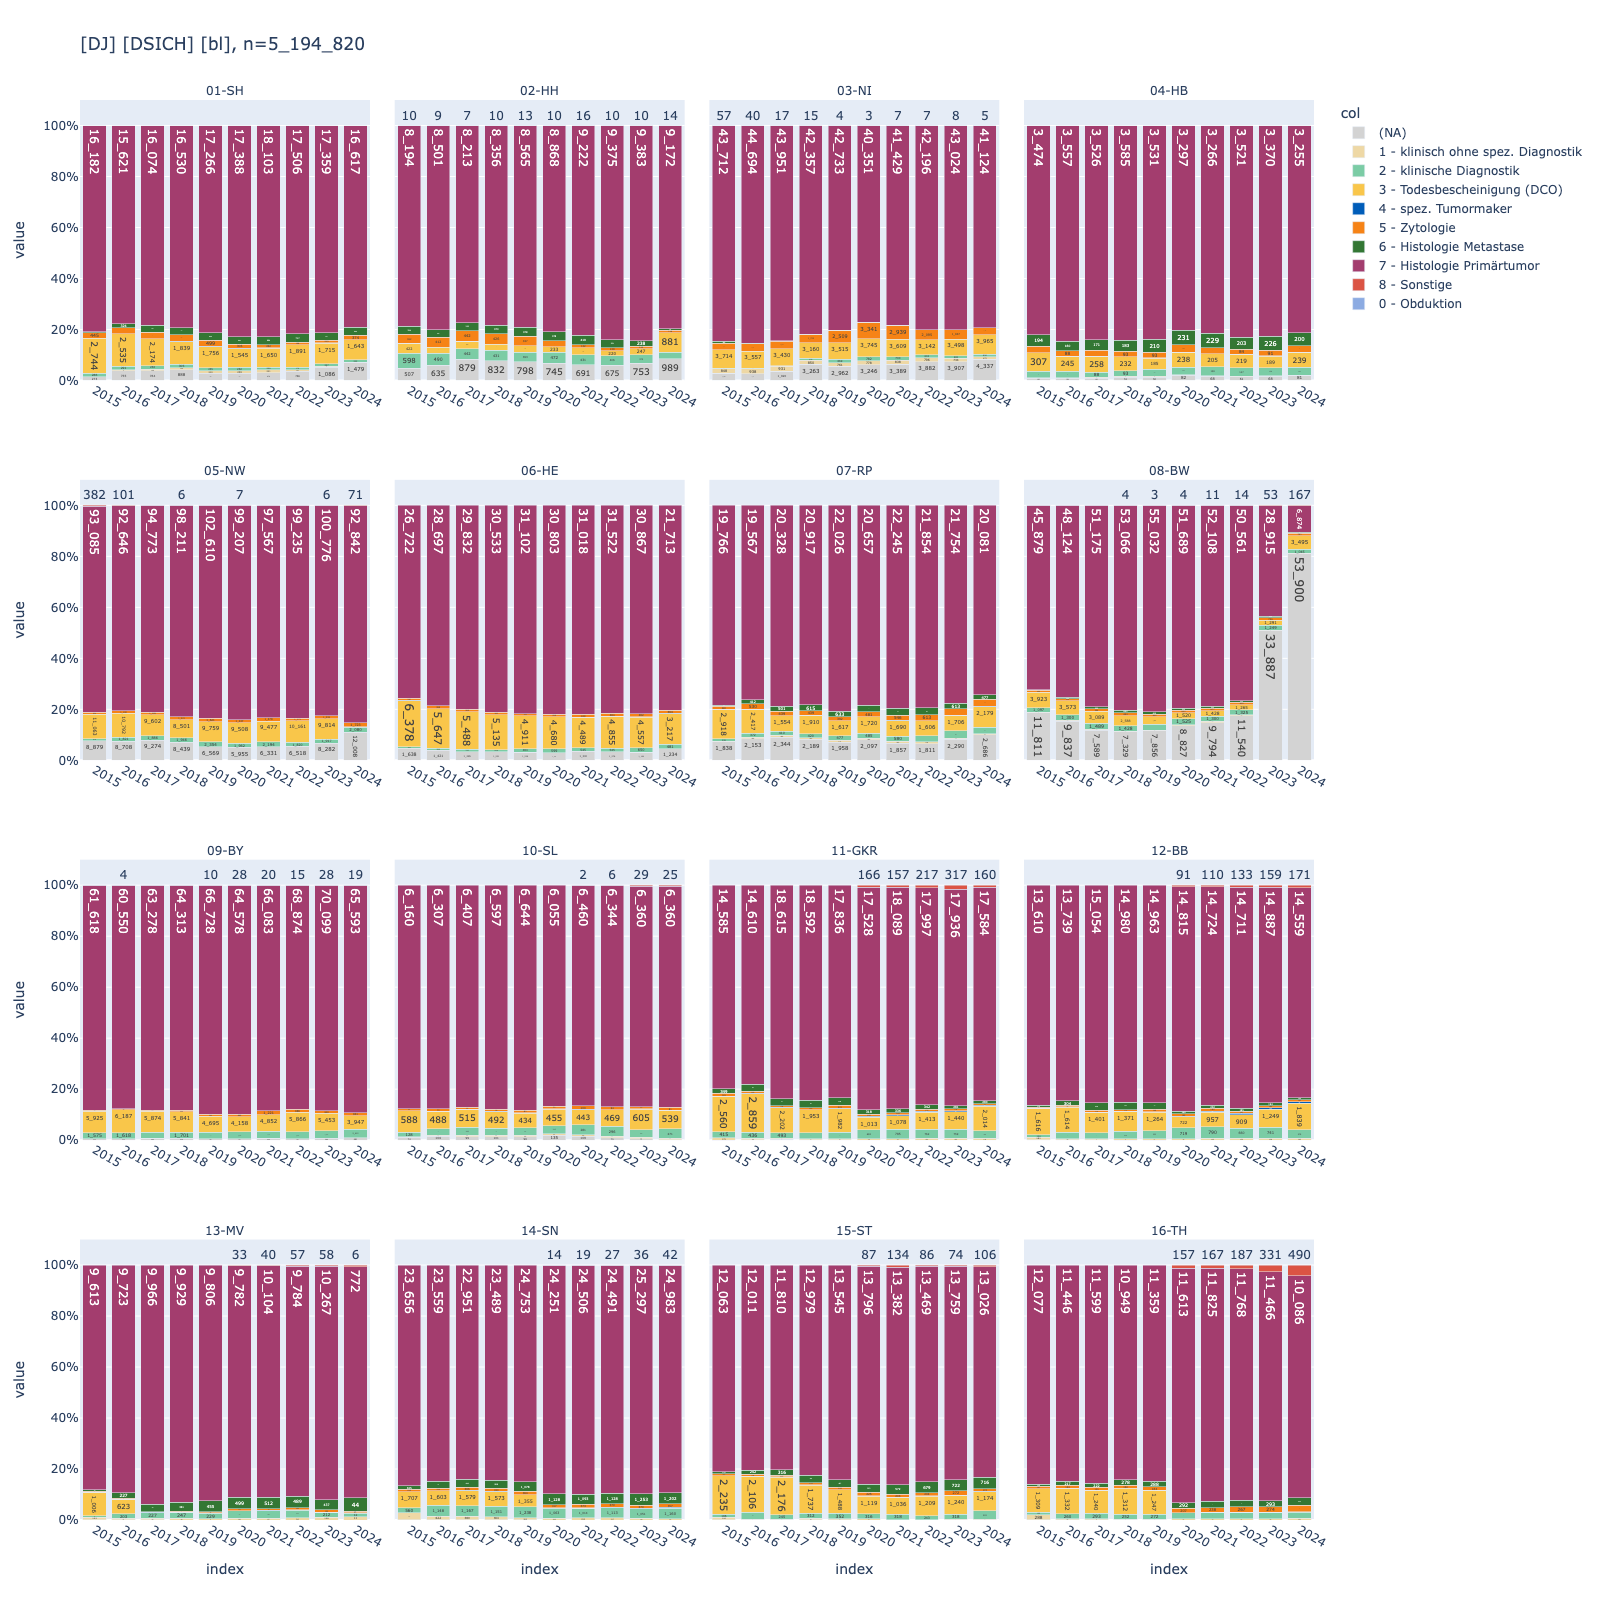

In [29]:
_filters = [
    FILTERS_VALID,
    # ("DJ >= 2010", "DJ ab 2010"),
    ("DJ >= 2015", "DJ ab 2015"),
    FILTERS_C,
    FILTERS_NO_C44,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        DJ,
        label as DSICH,
        GKZbl_label as bl,
    from tumor_epi_clin_all tum
    left join dim_dsich_epi ds on tum.DSICH::text = ds.code
    where {_filter}
    """
).to_df()
_ = pls.plot_facet_stacked_bars(
    _df,
    relative=True,
    subplot_size=400,
    sort_values_facet=True,
    # sort_values_index=True,
    annotations=True,
    color_palette=const.PALETTE_RKI2,
)

<!-- <br>

### <a id='toc1_5_4_'></a>[DCO Diagramm](#toc0_)
- **Filter: DJ = 2020-2024, C44 und D-Diagnosen sind ausgeschlossen, GKZbl 01-16**
- die epi Variable `DCO` wird wie folgt gebildet:
  - 1 wenn Diagnosesicherung = 3
  - sonst 2 (auch für Diagnosesicherung missing)  -->

### <a id='toc1_5_5_'></a>[DCO](#toc0_)
- Metrik: Anteil DCO an Gesamtfallzahl in %

> 💡 **ZfKD**
> 
> Fehlende DCO Fälle bzw Markierungen
> * es ist nicht ersichtlich, ob DCO Fälle nicht übermittelt oder nicht markiert sind
> * `05-NW` hat fast keine DCO Fälle im aktuelle Jahr
> * `08-BW` keine / kaum DCO Fälle vor 2015
> * `13-MV` `14-SN` `16-TH` haben kaum DCO Fälle seit Beginn der klinischen Lieferungen


In [17]:
_filters = [
    FILTERS_VALID,
    FILTERS_C,
    FILTERS_NO_C44,
    ("z_dy between 2010 and 2024","DJ 2010-2024"),
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_dco = con.sql(f"""--sql
    with t_all as (
        select
            GKZbl_label as bl,
            z_is_dco,
            z_dy,
            z_icd10_3d,
            is_deleted,
        from tumor_epi_clin_all
    )
    select  bl, z_dy,
            count(*) as cnt,
            sum(z_is_dco) as sum_dco,
            sum(z_is_dco) / cnt * 100 as pct_dco,
    from    t_all
    where {_filter}
    group by all
    union
    select  'Total' as bl,
            z_dy,
            count(*) as cnt,
            sum(z_is_dco) as sum_dco,
            sum(z_is_dco) / cnt * 100 as pct_dco,
    from    t_all
    where {_filter}
    group by all
    """)
# tbl.descr_db(db_dco, "dco data")

tbl.pivot_df(
    db_dco.project("bl, z_dy, pct_dco").to_df(),
    swap=True,
    precision=2,
    pct_axis="",
    total_axis="",
    font_size_th=12,
    font_size_td=11,
)

<!-- START_TOKEN -->

n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [ICD10 nur C]:            n = 14_973_906  (85.2%) ░░░░░█████████████████████████
└ [keine C44,D04]:          n = 12_161_317  (69.2%) ░░░░░░░░░░████████████████████
└ [DJ 2010-2024]:            n = 7_646_321  (43.5%) ░░░░░░░░░░░░░░░░░█████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
and z_dy between 2010 and 2024
```

</details>

bl,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,12-BB,13-MV,14-SN,15-ST,16-TH,Total
z_dy,,,,,,,,,,,,,,,,,
2010,14.04,6.84,8.24,3.35,14.02,17.36,12.12,0,10.66,4.20,7.97,5.28,5.37,3.71,11.37,7.38,9.94
2011,14.33,4.84,7.84,4.33,11.96,16.91,15.18,0,9.70,4.11,7.04,5.37,4.59,3.65,12.52,6.87,9.14
2012,14.85,5.20,8.28,4.48,10.85,17.02,14.54,0,9.31,4.84,12.74,5.77,4.44,3.07,12.19,6.11,8.94
2013,13.91,5.01,7.37,6.33,10.81,18.08,16.79,0,8.78,6.55,12.37,5.55,4.66,2.88,12.68,5.96,8.79
2014,13.90,3.66,7.18,11.47,10.14,18.02,15.95,0.10,8.42,9.96,11.23,5.43,4.16,2.64,11.59,6.40,8.57
2015,13.72,4.05,7.19,7.25,9.60,18.07,11.57,6.18,8.48,8.37,14.01,10.25,9.22,6.25,15.00,9.32,9.61
2016,12.61,2.46,6.79,5.83,9.36,15.48,9.42,5.59,8.96,6.78,15.26,9.93,5.72,5.77,14.10,9.87,9.04
2017,10.59,2.98,6.59,6.15,8.23,14.72,6.02,4.77,8.19,7.00,9.90,7.94,0.19,5.78,14.78,9.15,7.91
2018,8.82,2.44,6.10,5.45,7.18,13.65,7.15,3.92,8.01,6.56,8.87,7.79,0.18,5.65,11.03,10.10,7.24


### <a id='toc1_5_6_'></a>[Angabe Register vs Bundesland](#toc0_)
- neue Bundesländer sind nicht aufgeführt, da Daten erst ab 2020 aus Länderregistern vorliegen
- Fälle ausserhalb des Einzugsbereichs werden im ZfKD ausgeschlossen (`A_EKRNR_GKZ_unplausibel`)

> 💡 **ZfKD**
> 
> Fallübermittlung außerhalb des Einzugsbereichs
> * generell wird angestrebt, dass die Fallübermittlung ausschließlich innerhalb des Einzugsbereichs stattfindet
> * `05-NW` übermittelt einen relativ hohen Anteil an Fällen aus anderen Bundesländern

In [18]:
_filters = [
    ("z_kkr < 11", "keine NBL"),
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_db = con.sql(f"""--sql
select
    GKZbl_label as bl,
    --lpad(z_gkzbl::text, 2, '0') as z_gkzbl,
    lpad(z_kkr::text, 2, '0') as z_kkr,
    count(*) as cnt,
from tumor_epi_clin_all
where {_filter}
group by all
""")

# _db.show()

tbl.pivot_df(
    _db.to_df(),
    pct_axis="x",
    # font_size_th=12,
    # font_size_td=11,
)

<!-- START_TOKEN -->

n = 17_569_016                (100.0%) ██████████████████████████████
└ [keine NBL]: n = 13_493_606  (76.8%) ░░░░░░░███████████████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_kkr < 11
```

</details>

z_kkr,01,02,03,04,05,06,07,08,09,10,Total
bl,,,,,,,,,,,
(NA),0,0,0,0,9_615 (0.2%),0,0,0,0,0,9_615 (0.1%)
01-SH,824_131 (100.0%),0,0,0,3_719 (0.1%),0,0,0,0,0,827_850 (6.1%)
02-HH,0,462_565 (100.0%),0,0,2_513 (0.1%),0,0,0,0,0,465_078 (3.4%)
03-NI,0,0,2_007_107 (100.0%),0,113_885 (2.6%),0,0,0,0,0,2_120_992 (15.7%)
04-HB,0,0,0,162_936 (100.0%),2_530 (0.1%),0,0,0,0,0,165_466 (1.2%)
05-NW,0,0,0,0,4_064_517 (92.3%),0,0,0,0,0,4_064_517 (30.1%)
06-HE,0,0,0,0,35_494 (0.8%),1_010_507 (100.0%),0,0,0,0,1_046_001 (7.8%)
07-RP,0,0,0,0,73_870 (1.7%),0,903_789 (100.0%),0,0,0,977_659 (7.2%)
08-BW,0,0,0,0,48_614 (1.1%),0,0,1_259_176 (100.0%),0,0,1_307_790 (9.7%)


<br>

### <a id='toc1_5_7_'></a>[Dignität](#toc0_)

<!-- START_TOKEN -->

n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2020-2024]:            n = 3_814_755  (21.7%) ░░░░░░░░░░░░░░░░░░░░░░░░██████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy between 2020 and 2024
```

</details>

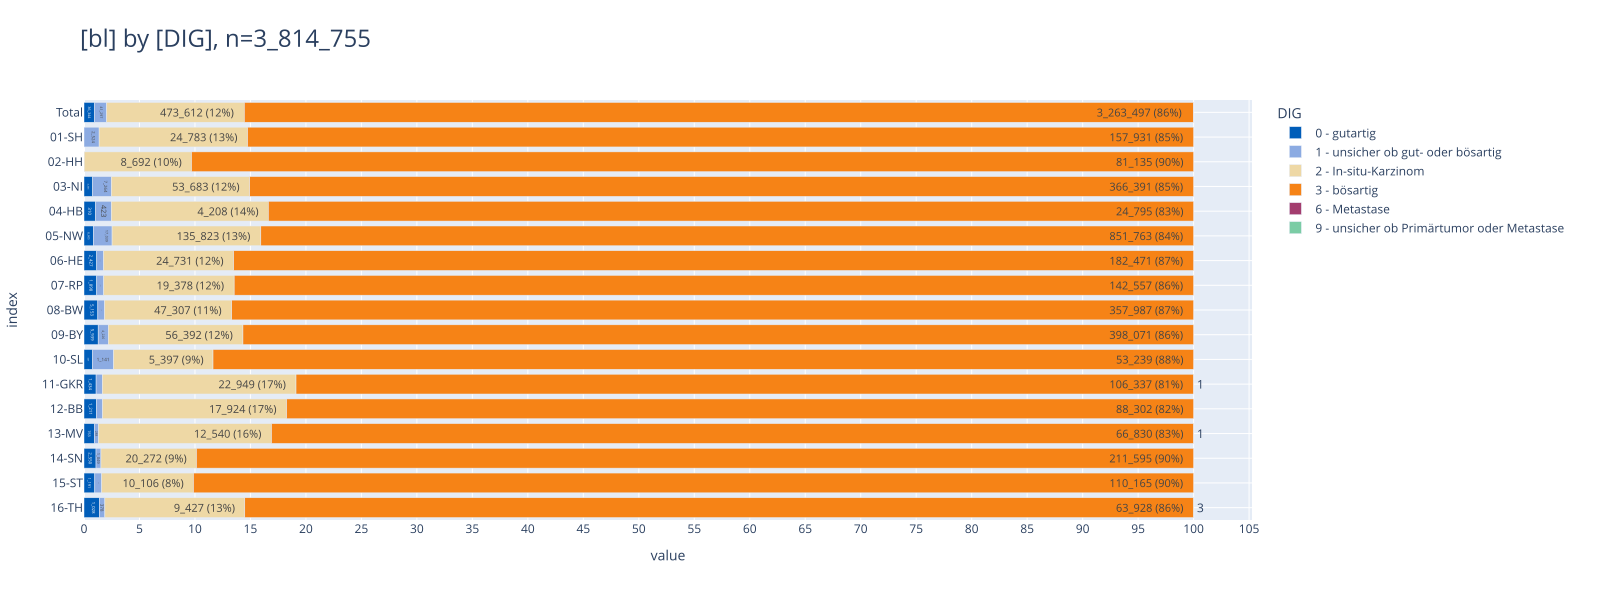

In [23]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY,
    # FILTERS_C,
    # FILTERS_NO_C44,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        --z_dy::text as z_dy,
        --DIG,
        GKZbl_label as bl,
        label as DIG,
        count(*) as cnt,
    from tumor_epi_clin_all tum
    left join dim_dig dig on tum.DIG  = dig.code
    where {_filter}
    group by all
    """
).to_df()
# _df

# _ = pls.plot_facet_stacked_bars(
#     _df,
#     subplot_size=400,
#     relative=True,
#     annotations=True,
#     sort_values_facet=True,
# )

_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    # height=700,
    show_pct_bar=True,
)

<br>

### <a id='toc1_5_8_'></a>[Grading Verteilung](#toc0_)
❓filter

<!-- START_TOKEN -->

n = 17_569_016                                  (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]:      n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2020-2024]:                 n = 3_814_755  (21.7%) ░░░░░░░░░░░░░░░░░░░░░░░░██████
└ [keine DCO]:                    n = 3_643_458  (20.7%) ░░░░░░░░░░░░░░░░░░░░░░░░██████
└ [nur gradingrelevante Tumore]:  n = 1_238_330   (7.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy between 2020 and 2024
and not z_is_dco
and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 33
            or right(z_icd10_3d, 2)::int8 between 50 and 57
            or right(z_icd10_3d, 2)::int8 between 63 and 68
            or right(z_icd10_3d, 2)::int8 = 60
        )
        and left(Morphologie_Code,4)::int between 8010 and 8576
    )
```

</details>

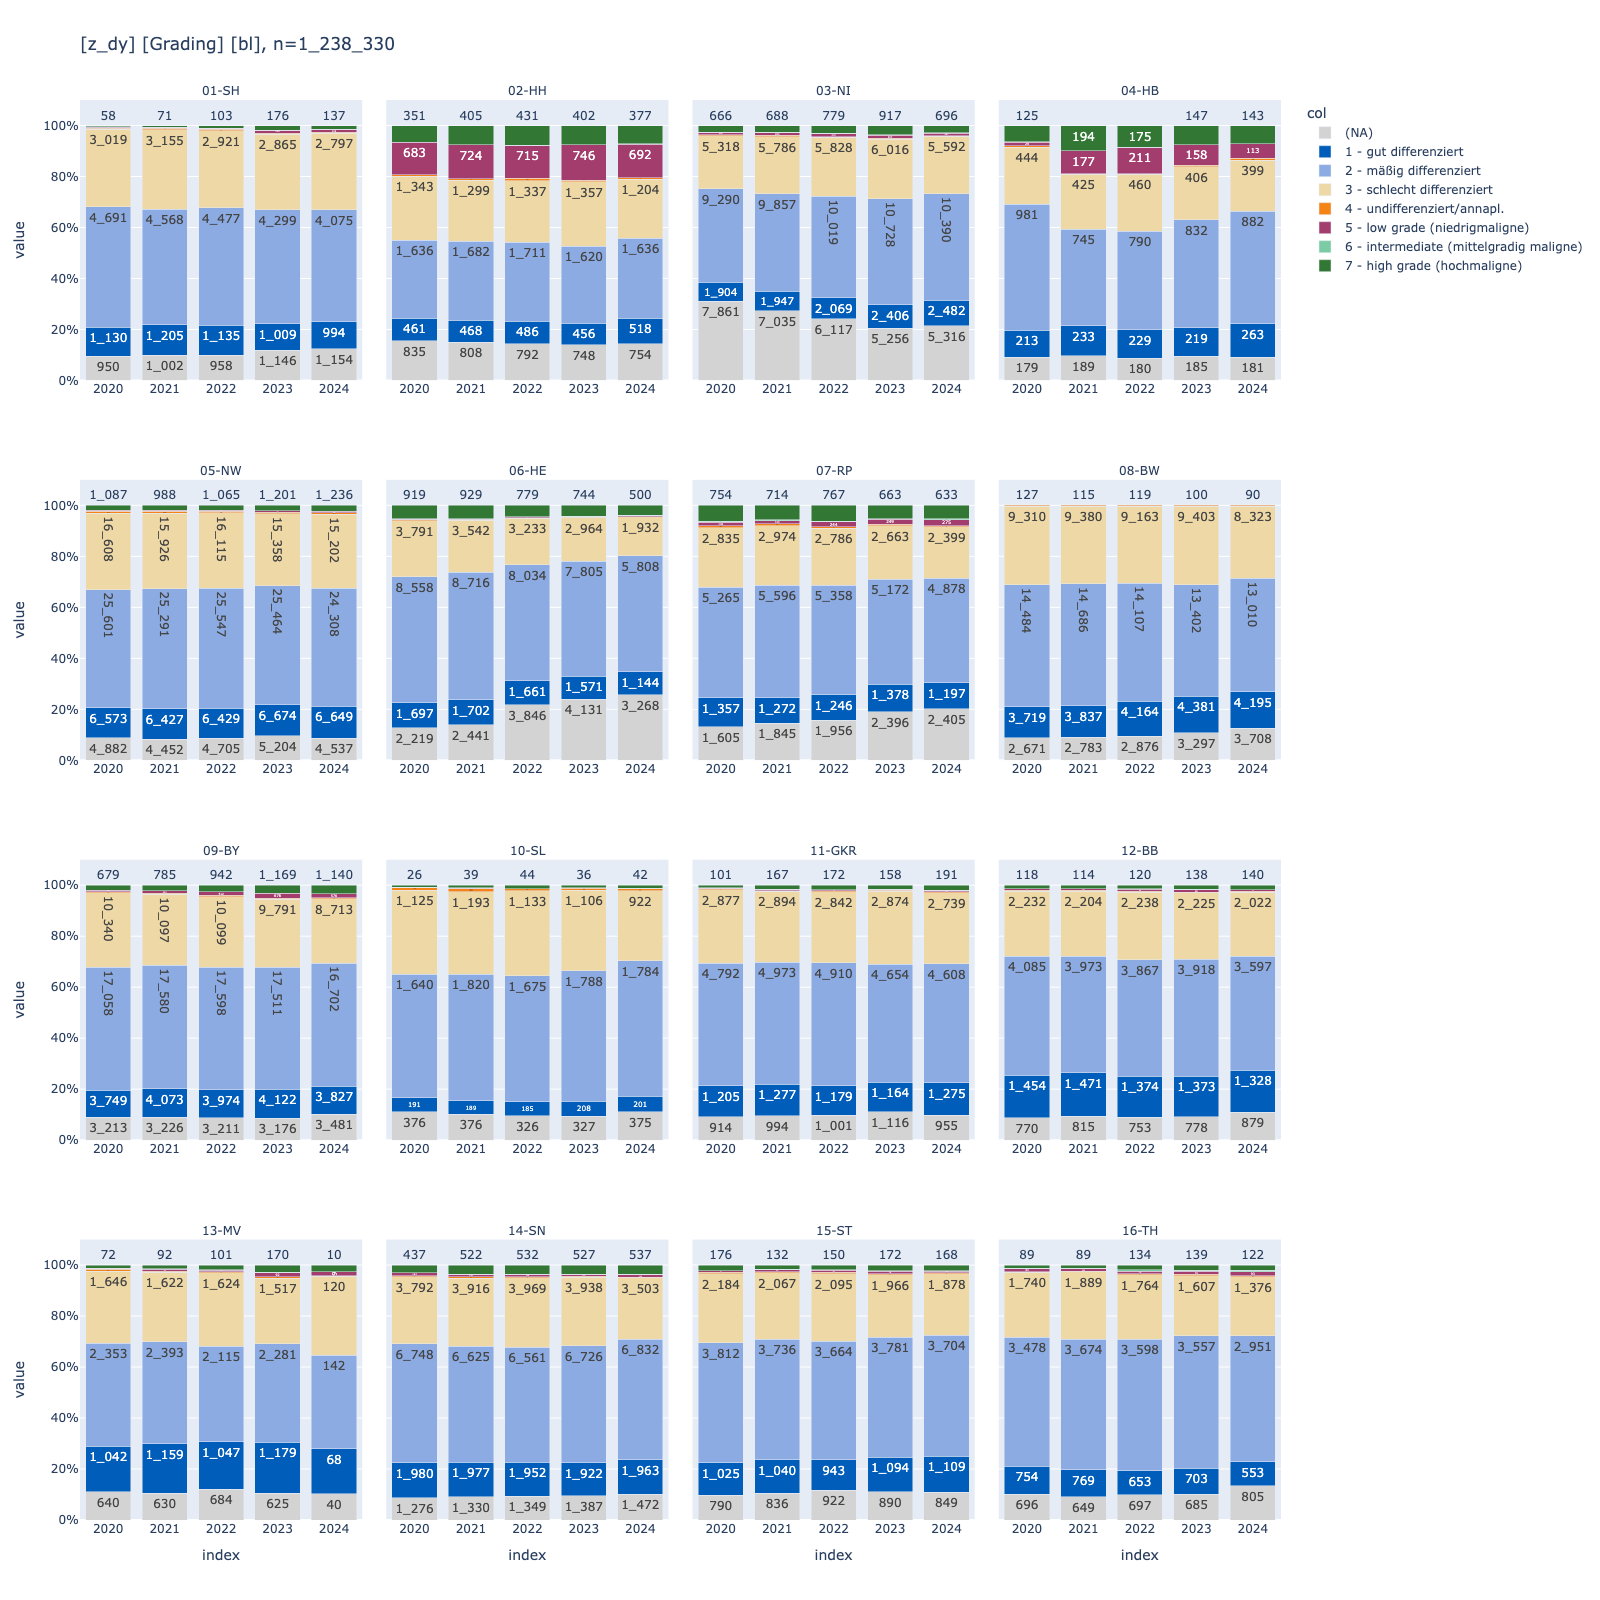

In [34]:
_filters = [
    FILTERS_VALID,
    # FILTERS_DY_MAX,
    FILTERS_DY,
    # FILTERS_C,
    # FILTERS_NO_C44,
    FILTERS_NO_DCO,
    FILTERS_GRAD,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        z_dy::text as z_dy,
        GKZbl_label as bl,
        label as Grading,
        count(*) as cnt,
    from tumor_epi_clin_all tum
    left join dim_grading_epi gr on tum.GRAD  = gr.code
    where {_filter}
    group by all
    """
).to_df()
# display(_df)

# _=pls.plot_stacked_bars(
#     _df[["bl", "Grading", "cnt"]],
#     orientation="h",
#     normalize=False,
#     relative=True,
#     dropna=False,
#     sort_values_index=False,
#     show_total=True,
#     # height=700,
#     show_pct_bar=True,
# )

_ = pls.plot_facet_stacked_bars(
    _df[["z_dy", "Grading", "bl", "cnt"]],
    relative=True,
    subplot_size=400,
    sort_values_facet=True,
    # sort_values_index=True,
    annotations=True,
    # color_palette=const.PALETTE_RKI2,
)

### <a id='toc1_5_9_'></a>[Grading Anteil](#toc0_)
- Metrik: Anteil `Grading` missings an Gesamt

In [21]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY,
    FILTERS_NO_DCO,
    FILTERS_GRAD,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df=con.sql(query=f"""--sql
    with t1 as (
        select
            z_dy::text as z_dy,
            GKZbl_label as bl,
            GRAD,
            case
                when GRAD is null then '1_null'
                else '2_notnull'
            end as categ_tnm,
        from tumor_epi_clin_all
        where {_filter}
    ),
    t2 as (
        select
            z_dy::text as z_dy,
            bl,
            count(*) as cnt,
            count(*) filter (where GRAD is null) as cnt_null,
            cnt_null / cnt as pct_null,
        from t1
        group by all

        union
        select
            'Total' as z_dy,
            bl,
            count(*) as cnt,
            count(*) filter (where GRAD is null) as cnt_null,
            cnt_null / cnt as pct_null,
        from t1
        group by all
        union
        select
            z_dy::text as z_dy,
            'Total' as bl,
            count(*) as cnt,
            count(*) filter (where GRAD is null) as cnt_null,
            cnt_null / cnt as pct_null,
        from t1
        group by all
        
        union
        select
            'Total' as z_dy,
            'Total' as bl,
            count(*) as cnt,
            count(*) filter (where GRAD is null) as cnt_null,
            cnt_null / cnt as pct_null,
        from t1
        group by all

    )
    select * from t2
    """).to_df()
# display(_df)

tbl.pivot_df(
    _df[["z_dy", "bl", "pct_null"]],
    precision=2,
    show_as_pct=True,
    pct_axis="",
    total_axis="",
    font_size_th=12,
    font_size_td=11,
    swap=True,
    image_scale="80%",
    kpi_mode="min_max_x",
)


<!-- START_TOKEN -->

n = 17_569_016                                  (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]:      n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2020-2024]:                 n = 3_814_755  (21.7%) ░░░░░░░░░░░░░░░░░░░░░░░░██████
└ [keine DCO]:                    n = 3_643_458  (20.7%) ░░░░░░░░░░░░░░░░░░░░░░░░██████
└ [nur gradingrelevante Tumore]:  n = 1_238_330   (7.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy between 2020 and 2024
and not z_is_dco
and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 33
            or right(z_icd10_3d, 2)::int8 between 50 and 57
            or right(z_icd10_3d, 2)::int8 between 63 and 68
            or right(z_icd10_3d, 2)::int8 = 60
        )
        and left(Morphologie_Code,4)::int between 8010 and 8576
    )
```

</details>

<!-- SCALE-80% -->

z_dy,2020,2021,2022,2023,2024,Total
bl,,,,,,
01-SH,9.56% ⬜,9.93% ⬜,9.88% ⬜,11.88% ⬜,12.41% ⬜,10.70% ⬜
02-HH,15.66% ⬜,14.92% ⬜,14.35% ⬜,13.96% ⬜,14.47% ⬜,14.67% ⬜
03-NI,30.98% 🟥,27.33% 🟥,24.26% 🟥,20.38% ⬜,21.40% ⬜,24.88% 🟥
04-HB,9.02% ⬜,9.60% ⬜,8.78% ⬜,9.45% ⬜,9.05% ⬜,9.18% ⬜
05-NW,8.82% ⬜,8.29% 🟩,8.64% 🟩,9.55% ⬜,8.63% 🟩,8.79% 🟩
06-HE,12.82% ⬜,14.00% ⬜,21.77% ⬜,23.85% 🟥,25.68% 🟥,19.29% ⬜
07-RP,13.25% ⬜,14.53% ⬜,15.69% ⬜,19.00% ⬜,20.25% ⬜,16.52% ⬜
08-BW,8.81% ⬜,9.04% ⬜,9.45% ⬜,10.78% ⬜,12.64% ⬜,10.13% ⬜
09-BY,9.07% ⬜,8.90% ⬜,8.80% ⬜,8.68% 🟩,10.07% ⬜,9.09% ⬜


<br>

### <a id='toc1_5_10_'></a>[Altersgruppen Kinder und Heranwachsende](#toc0_)

<!-- START_TOKEN -->

n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2024]:                   n = 705_950   (4.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine C44,D04]:             n = 582_254   (3.3%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [Alter <= 20]:                 n = 1_975   (0.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy = 2024
and z_icd10_3d not in ('C44','D04')
and z_age<=20
```

</details>

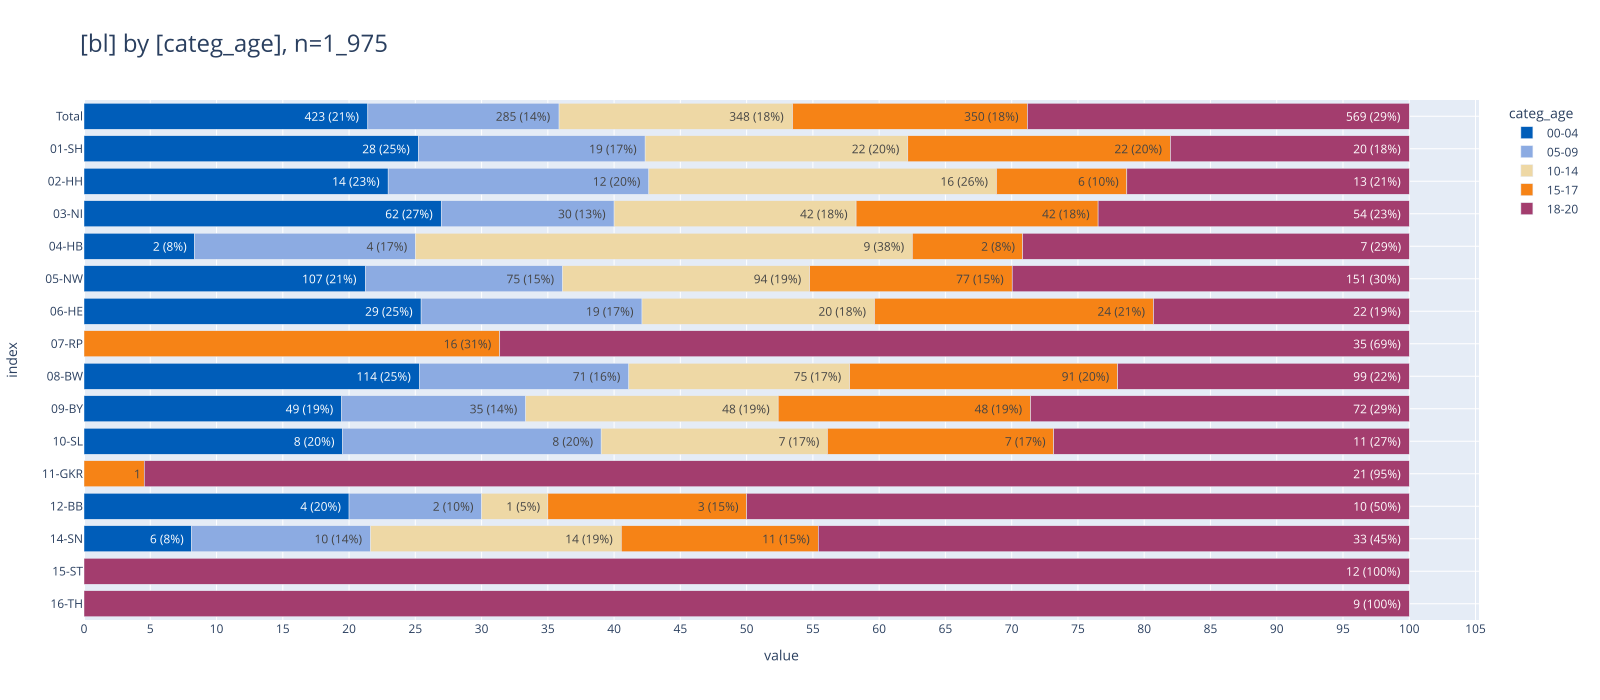

In [42]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY_MAX,
    # FILTERS_C,
    FILTERS_NO_C44,
    ("z_age<=20", "Alter <= 20"),
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        --z_dy::text as z_dy,
        GKZbl_label as bl,
        --z_ag05,
        --z_age,
        case
            when z_age::int between 0 and 4 then '00-04'
            when z_age::int between 5 and 9 then '05-09'
            when z_age::int between 10 and 14 then '10-14'
            when z_age::int between 15 and 17 then '15-17'
            when z_age::int between 18 and 20 then '18-20'
        else 'U' end as categ_age,
        count(*) as cnt,
    from tumor_epi_clin_all tum
    where {_filter}
    group by all
    """
).to_df()
# display(_df)

_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=700,
    show_pct_bar=True, 
)

<br>

### <a id='toc1_5_11_'></a>[UICC](#toc0_)
- die Variable `UICC` wird vom ZfKD gebildet

<!-- START_TOKEN -->

n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2024]:                   n = 705_950   (4.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [ICD10 nur C]:               n = 599_876   (3.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine C44,D04]:             n = 493_648   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy = 2024
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
```

</details>

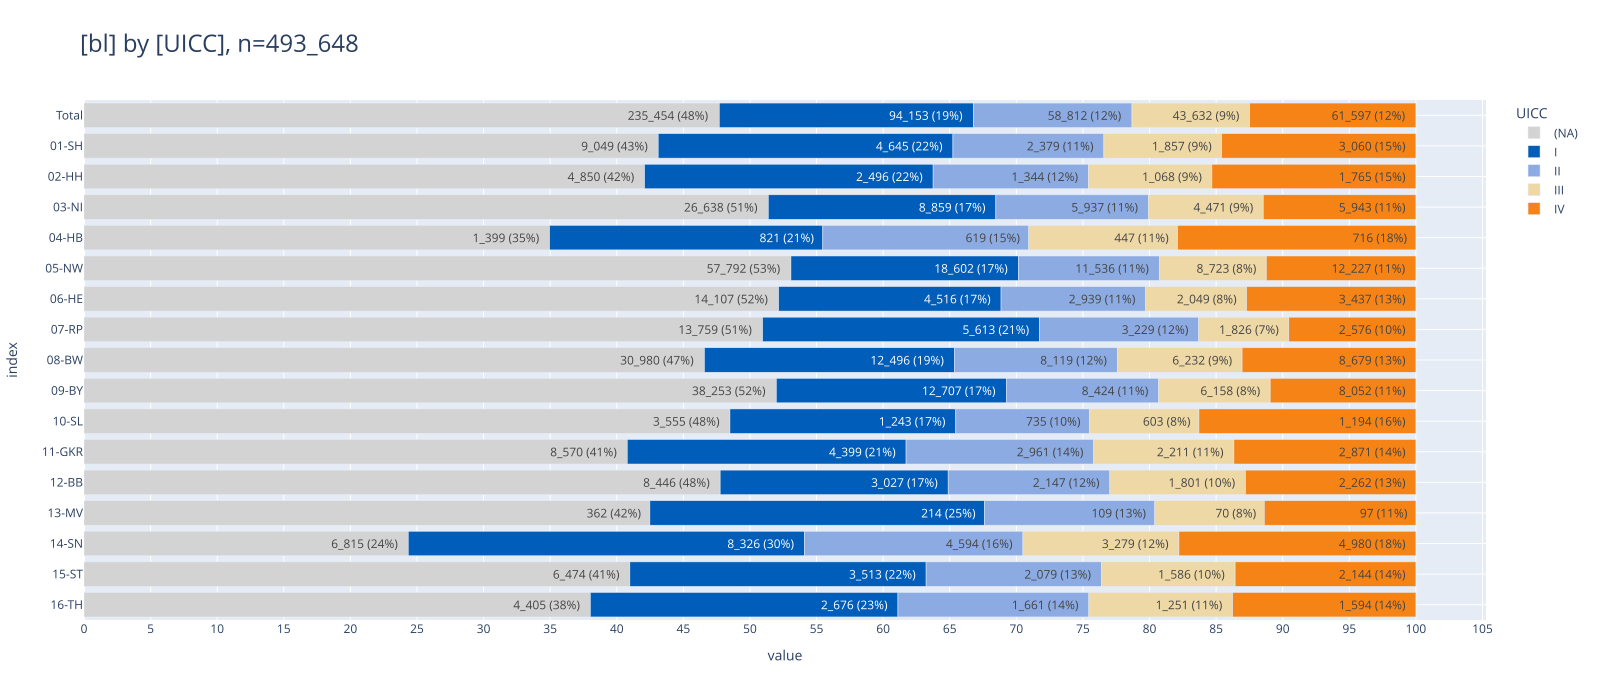

In [23]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY_MAX,
    FILTERS_C,
    FILTERS_NO_C44,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        GKZbl_label as bl,
        UICC,
    from tumor_epi_clin_all tum
    where {_filter}
    """
).to_df()
# display(_df)

_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=700,
    show_pct_bar=True,
)


<!-- START_TOKEN -->

n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ ab 2010]:             n = 11_220_232  (63.9%) ░░░░░░░░░░░███████████████████
└ [ICD10 nur C]:             n = 9_692_961  (55.2%) ░░░░░░░░░░░░░░████████████████
└ [keine C44,D04]:           n = 7_646_321  (43.5%) ░░░░░░░░░░░░░░░░░█████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and DJ >= 2010
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
```

</details>

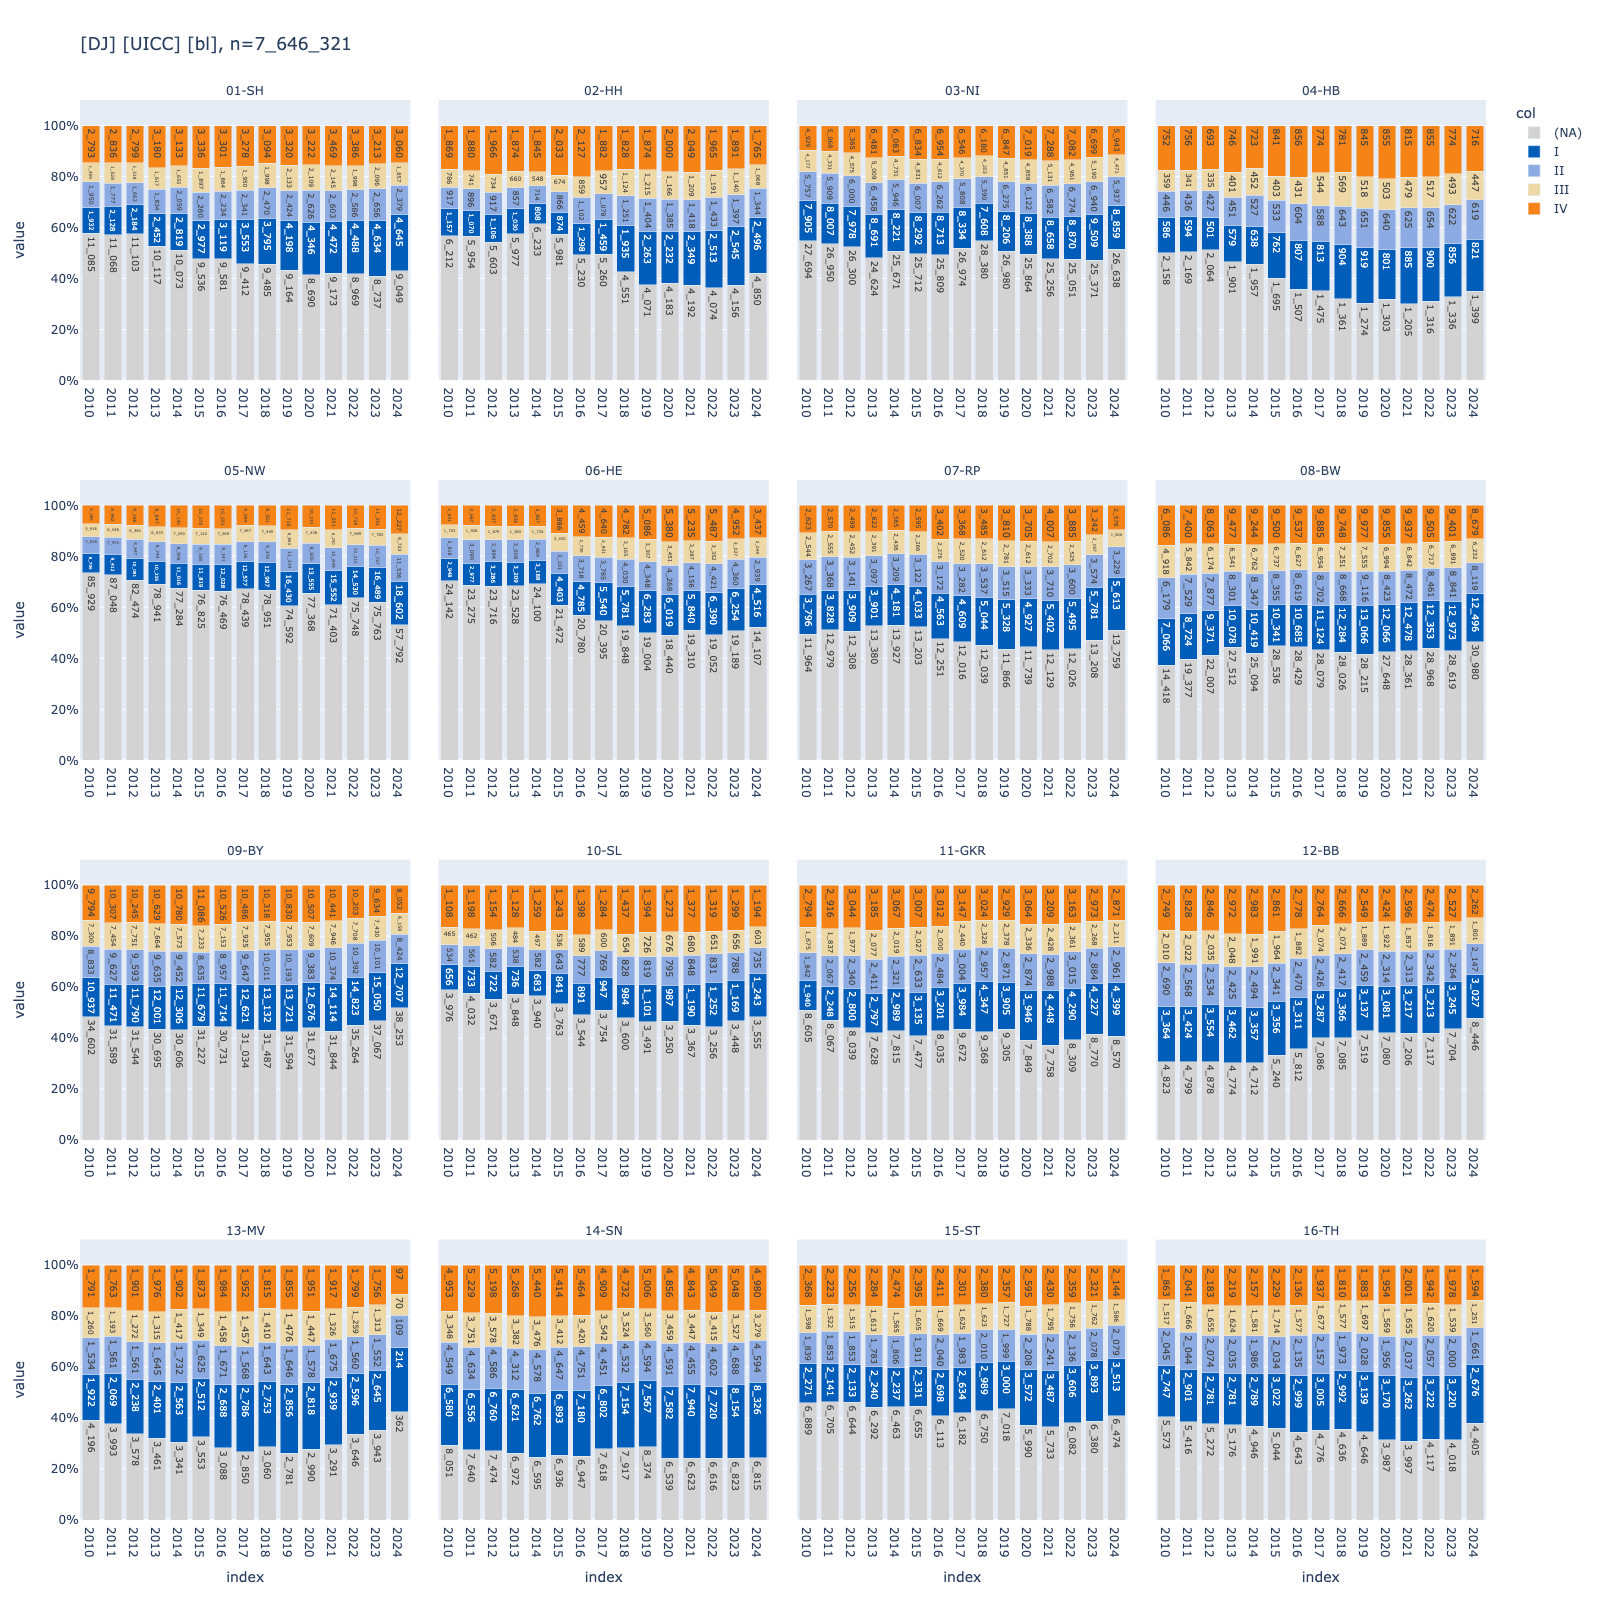

In [25]:
_filters = [
    FILTERS_VALID,
    ("DJ >= 2010", "DJ ab 2010"),
    # ("DJ >= 2015", "DJ ab 2015"),
    FILTERS_C,
    FILTERS_NO_C44,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        DJ,
        UICC,
        GKZbl_label as bl,
    from tumor_epi_clin_all tum
    where {_filter}
    """
).to_df()
_ = pls.plot_facet_stacked_bars(
    _df,
    relative=True,
    subplot_size=400,
    sort_values_facet=True,
    # sort_values_index=True,
    annotations=True,
)


<br>

### <a id='toc1_5_12_'></a>[TNM-Auflage](#toc0_)
- nicht übermittelte Auflagen werden im ZfKD geschätzt und imputiert anhand des DJ, daher keine missings im Datensatz

> 💡 **ZfKD**
> 
> Auflage 7 wird nur noch von 03-NI in nennenswertem Umfang übermittelt

<!-- START_TOKEN -->

n = 17_569_016                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 16_964_151  (96.6%) ░░████████████████████████████
└ [DJ 2024]:                   n = 705_950   (4.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [ICD10 nur C]:               n = 599_876   (3.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine C44,D04]:             n = 493_648   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy = 2024
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
```

</details>

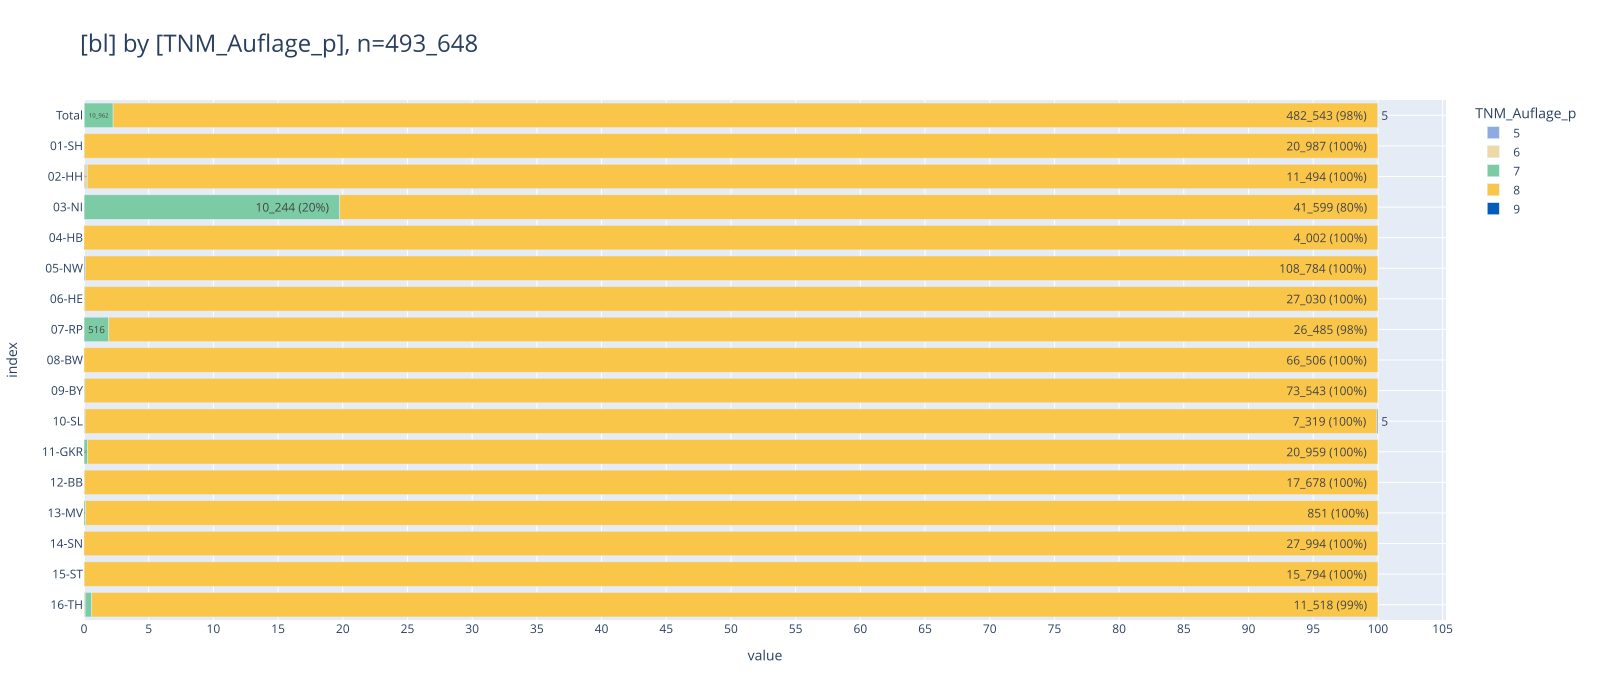

In [25]:
_filters = [
    FILTERS_VALID,
    FILTERS_DY_MAX,
    FILTERS_C,
    FILTERS_NO_C44,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    select
        GKZbl_label as bl,
        TNM_Auflage_p,
    from tumor_epi_clin_all tum
    where {_filter}
    """
).to_df()
# display(_df)

_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=700,
    show_pct_bar=True,
    color_palette=const.PALETTE_RKI2,
)

<br>

### <a id='toc1_5_13_'></a>[Tod](#toc0_)

#### <a id='toc1_5_13_1_'></a>[Anteil Verstorbene](#toc0_)
- gezählt sind **Personen**
- Metrik: Anteil Verstorbene

In [26]:
_filters = [
    FILTERS_VALID,
    # FILTERS_DY_MAX,
    FILTERS_DY,
    FILTERS_C,
    FILTERS_NO_C44,
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    distinct_metric="GLOBALPATID",
    first_n_filter_apply_to_rows=0,
)

_df = con.sql(f"""--sql
    with t1 as (
    select
        z_pat_id,
        any_value(z_dy::text) as z_dy,
        any_value(GKZbl_label) as bl,
        any_value(Verstorben) as Verstorben,
    from tumor_epi_clin_all
    where {_filter}
    group by z_pat_id
    ),
    t2 as (
        select
            z_dy::text as z_dy,
            bl,
            count(*) as cnt,
            count(*) filter (where Verstorben = 'J') as cnt_deceased,
            cnt_deceased / cnt as pct_deceased,
        from t1
        group by all
        
        union
        select
            'Total' as z_dy,
            bl,
            count(*) as cnt,
            count(*) filter (where Verstorben = 'J') as cnt_deceased,
            cnt_deceased / cnt as pct_deceased,
        from t1
        group by all
        
        union
        select
            z_dy::text as z_dy,
            'Total' as bl,
            count(*) as cnt,
            count(*) filter (where Verstorben = 'J') as cnt_deceased,
            cnt_deceased / cnt as pct_deceased,
        from t1
        group by all
        
        union
        select
            'Total' as z_dy,
            'Total' as bl,
            count(*) as cnt,
            count(*) filter (where Verstorben = 'J') as cnt_deceased,
            cnt_deceased / cnt as pct_deceased,
        from t1
        group by all
    )
    select * from t2
    """
).to_df()
# display(_df)

tbl.pivot_df(
    _df[["z_dy", "bl", "pct_deceased"]],
    total_axis="",
    pct_axis="",
    show_as_pct=True,
    precision=1,
    font_size_th=12,
    font_size_td=11,
    swap=True,
    image_scale="60%",
)

<!-- START_TOKEN -->

count: distinct GLOBALPATID
---
n = 14_998_886                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 14_585_410  (97.2%) ░█████████████████████████████
└ [DJ 2020-2024]:            n = 3_548_356  (23.7%) ░░░░░░░░░░░░░░░░░░░░░░░███████
└ [ICD10 nur C]:             n = 3_021_090  (20.1%) ░░░░░░░░░░░░░░░░░░░░░░░░██████
└ [keine C44,D04]:           n = 2_486_711  (16.6%) ░░░░░░░░░░░░░░░░░░░░░░░░░░████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and z_dy between 2020 and 2024
and left(z_icd10_3d,1) = 'C'
and z_icd10_3d not in ('C44','D04')
```

</details>

<!-- SCALE-60% -->

z_dy,2020,2021,2022,2023,2024,Total
bl,,,,,,
01-SH,48.5%,44.9%,41.8%,35.7%,27.7%,39.7%
02-HH,44.1%,40.6%,35.4%,28.4%,20.8%,33.7%
03-NI,48.7%,45.2%,40.9%,34.1%,22.9%,38.4%
04-HB,51.1%,46.1%,41.6%,34.4%,21.6%,39.1%
05-NW,46.4%,43.4%,38.9%,31.3%,11.6%,34.6%
06-HE,48.4%,44.5%,40.6%,33.9%,25.5%,39.4%
07-RP,44.5%,40.2%,35.9%,28.4%,18.9%,33.7%
08-BW,41.9%,37.4%,32.1%,25.5%,16.9%,30.6%
09-BY,41.5%,38.1%,33.5%,25.2%,13.9%,30.5%


#### <a id='toc1_5_13_2_'></a>[Verteilung Todesursachen nach ICDT10](#toc0_)
- gezählt sind **Personen**
- `icdt10_1d` gibt die erste Stelle der Todesursache (TU) an


> 💡 **ZfKD**
> 
> Fehlende Angabe
> * `03-NI` hat für das aktuelle DJ nahezu keine TU mit nicht-tumorrelevanten TU übermittelt



<!-- START_TOKEN -->

count: distinct GLOBALPATID
---
n = 14_998_886                             (100.0%) ██████████████████████████████
└ [keine gelöschten Fälle]: n = 14_585_410  (97.2%) ░█████████████████████████████
└ [nur Verstorbene]:         n = 7_558_161  (50.4%) ░░░░░░░░░░░░░░░███████████████
└ [SJ ab 2010]:              n = 5_099_012  (34.0%) ░░░░░░░░░░░░░░░░░░░░██████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
is_deleted = 0
and Verstorben = 'J'
and year(SDIMP) >= 2010
```

</details>

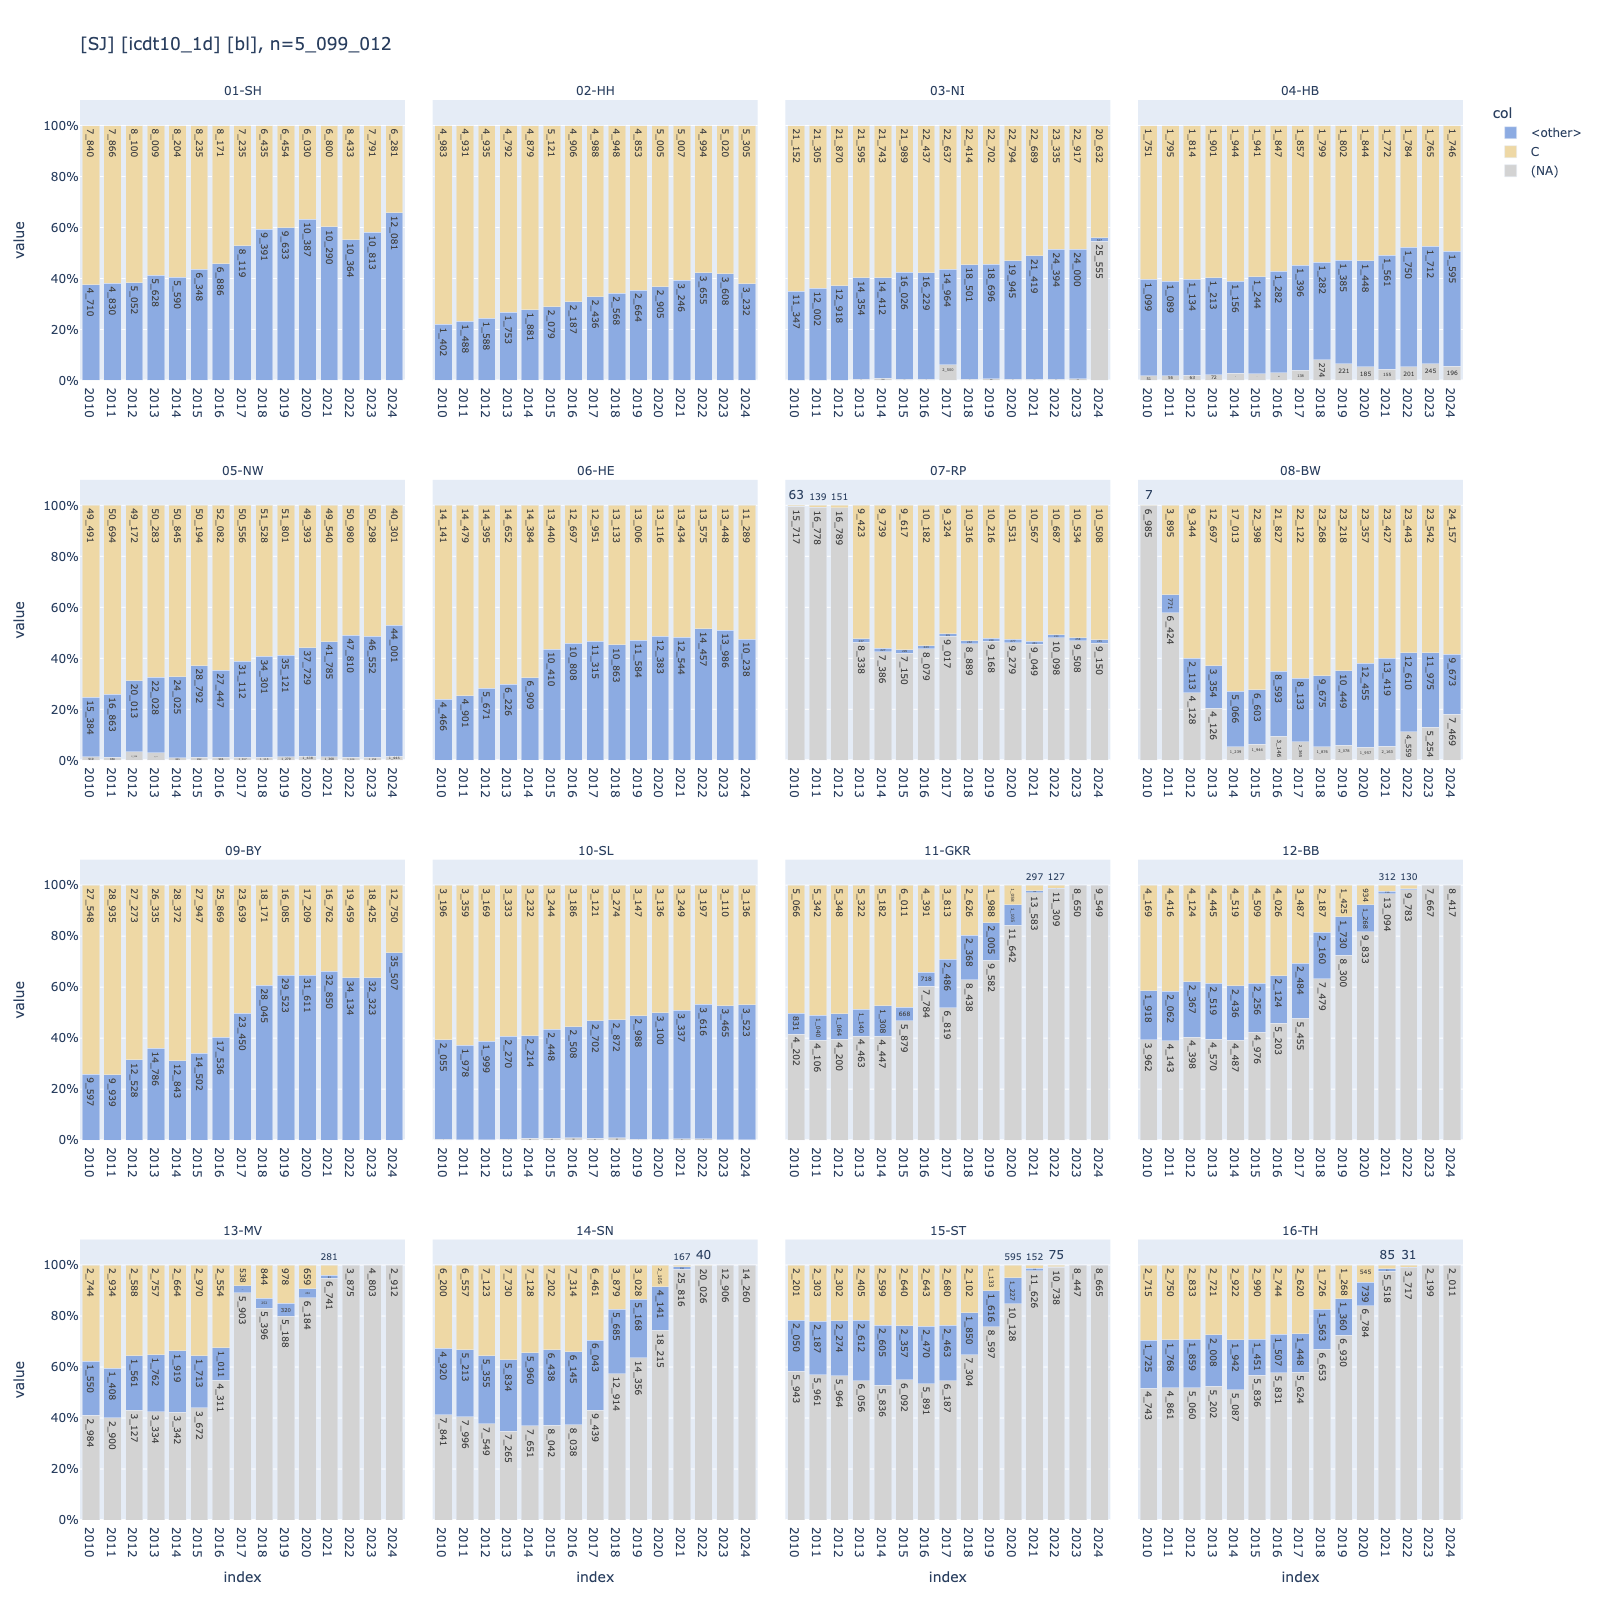

In [27]:
_filters = [
    FILTERS_VALID,
    ("Verstorben = 'J'", "nur Verstorbene"),
    ("year(SDIMP) >= 2010", "SJ ab 2010"),
]

_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from tumor_epi_clin_all",
    filters=_filters,
    distinct_metric="GLOBALPATID",
    first_n_filter_apply_to_rows=0,
)

_df = (con.sql(f"""--sql
    with t1 as (
        select
            year(SDIMP)::text as SJ,
            ICDT10,
            GKZbl_label as bl,
            case
                when ifnull(ICDT10,'') = '' then null
                when upper(left(ICDT10,1)) = 'C' then 'C'
            else '<other>' end as icdt10_1d,
            GLOBALPATID,
        from tumor_epi_clin_all
        where {_filter}
    ),
    t2 as (
        select 
            any_value(SJ) as SJ,
            any_value(icdt10_1d) as icdt10_1d,
            any_value(bl) as bl,
        from t1
        group by GLOBALPATID
    ),
    t3 as (
        select
            *,
            count(*) as cnt
        from t2
        group by all
    )
    select * from t3
    """)
    # .filter("SJ::int >= 2010 and GKZbl::int <= 16")
    .order("bl")
    .to_df()
)
# display(_df)

_ = pls.plot_facet_stacked_bars(
    _df,
    # df_tu[["SJ","icdt10_1d","GKZbl"]],
    # df_tu[["DJ","ICDT10","EKRNR"]],
    # top_n_color=5,
    subplot_size=400,
    sort_values_facet=True,
    # sort_values_index=True,
    relative=True,
    annotations=True,
    color_palette=const.PALETTE_RKI2,
)